In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
from numpy import float64
import time

In [2]:
import sys
import os
import importlib


# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import methods
importlib.reload(methods)
import solvers
importlib.reload(solvers)
import utils
importlib.reload(utils)

e:\anaconda3\envs\Graph_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from 'd:\\PhD at UCLA\\Allen-Cahn and Cahn-Hilliard\\SRK for Gradient Flows\\utils.py'>

In [3]:
# Time and space range
a_x = 0
b_x = 2 * np.pi
a_y = 0
b_y = 2 * np.pi

#Initial x grid size and t grid size
Nx = 256
Ny = 256

dx = float64((b_x - a_x) / Nx)
dy = float64((b_y - a_y) / Ny)

T = 2
eps = 0.1

# dt = 1 * dx**4 / eps**2
dt = 1e-2

bc= "Periodic"

save = True
save_path = "../../Results/Cahn_Hilliard_Coarsening/Constant_timestep"


print("Initial dt used is " + str(dt))
print("eps used is " + str(eps))
print("dt / dx^4 is " + str(dt / dx**4))

Initial dt used is 0.01
eps used is 0.1
dt / dx^4 is 27557.536278240983


In [4]:
'''
Initial Condition for the Cahn-Hilliard simulation
'''
def initial_condition(mesh_grid, seed=12345):
    X, _ = mesh_grid
    rng = np.random.default_rng(12345)
    core = 0.0025 + 0.004 * rng.uniform(-1.0, 1.0, size=(X.shape[0] - 1, X.shape[1] - 1))
    return np.pad(core, ((0, 1), (0, 1)), mode="wrap").astype(np.float64)

In [5]:
method = "RKL2_2D_CH"
# method = "RKG2_2D_CH"

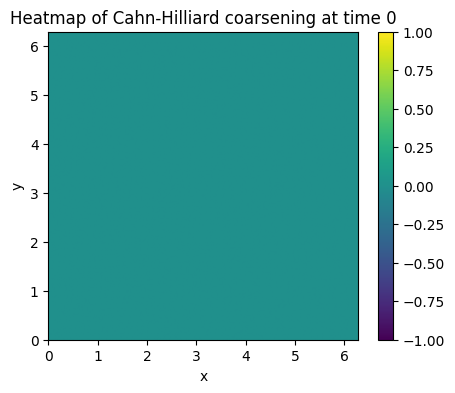

In [6]:
if method == "RKL2_2D_CH":
    my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep("RKL2_2D_CH", 200, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=50, save=save, save_path=save_path)
elif method == "RKG2_2D_CH":
    my_solver = solvers.Cahn_Hilliard_Solver_2D_Constant_Timestep("RKG2_2D_CH", 240, Nx, Ny, dt, dx, dy, a_x, b_x, a_y, b_y, initial_condition, T, eps, bc=bc, energy_case=3, plot_frequency=50, save=save, save_path=save_path)
else:
    raise ValueError("Invalid method")

my_solver.initialize(display=True)

Solving:   0%|                                                            | 0/201 [00:00<?, ?iter/s]

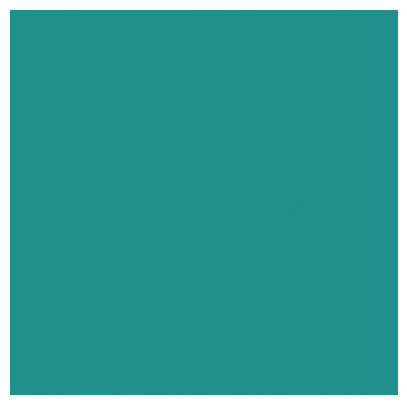

The max of u_total[-1] is 0.006499770714060462
The min of u_total[-1] is -0.001499958585917146


Solving:  25%|████████████▋                                      | 50/201 [01:06<02:25,  1.04iter/s]

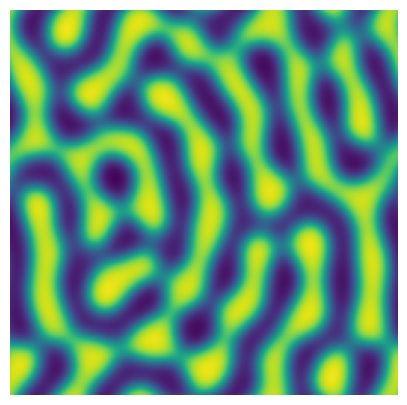

The max of u_total[-1] is 0.9608381650239842
The min of u_total[-1] is -0.9711944880100112


Solving:  50%|████████████████████████▉                         | 100/201 [01:54<01:39,  1.01iter/s]

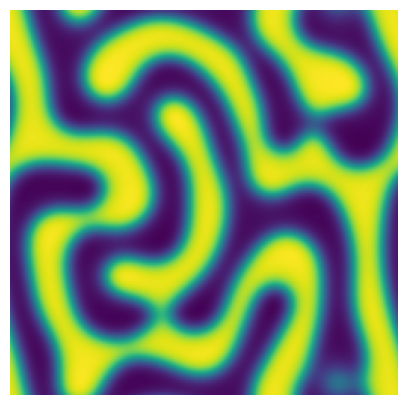

The max of u_total[-1] is 1.0062131559518772
The min of u_total[-1] is -0.993007185261724


Solving:  75%|█████████████████████████████████████▎            | 150/201 [03:02<00:49,  1.04iter/s]

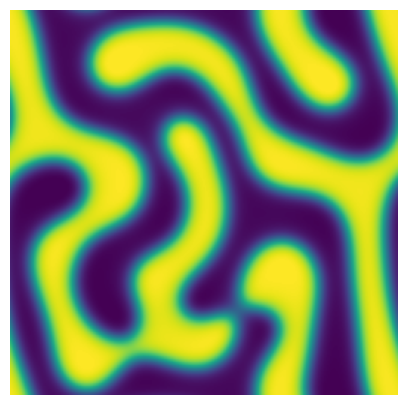

The max of u_total[-1] is 1.0241287641698589
The min of u_total[-1] is -1.0204553982042126


Solving: 100%|█████████████████████████████████████████████████▊| 200/201 [03:49<00:00,  1.07iter/s]

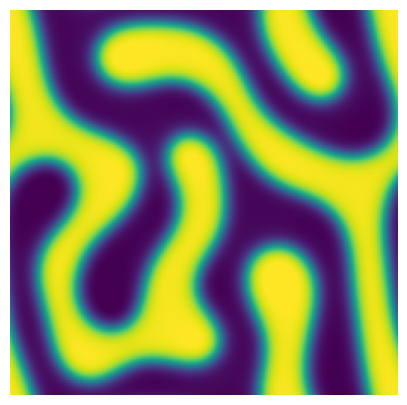

The max of u_total[-1] is 1.0277432418884325
The min of u_total[-1] is -1.0246212390655987


Solving: 100%|██████████████████████████████████████████████████| 201/201 [03:50<00:00,  1.15s/iter]


In [7]:
my_solver.solve()

In [8]:
u_total, t_total, energy_total, mesh_grid = my_solver.get_results()

Figure saved to ../../Results/Cahn_Hilliard_Coarsening/Constant_timestep/RKL2_2D_CH/RKL2_2D_CH_coarsening_Nx256_Ny256_dt0.01_eps0.1000_T2_bcPeriodic_energy_case3.pdf


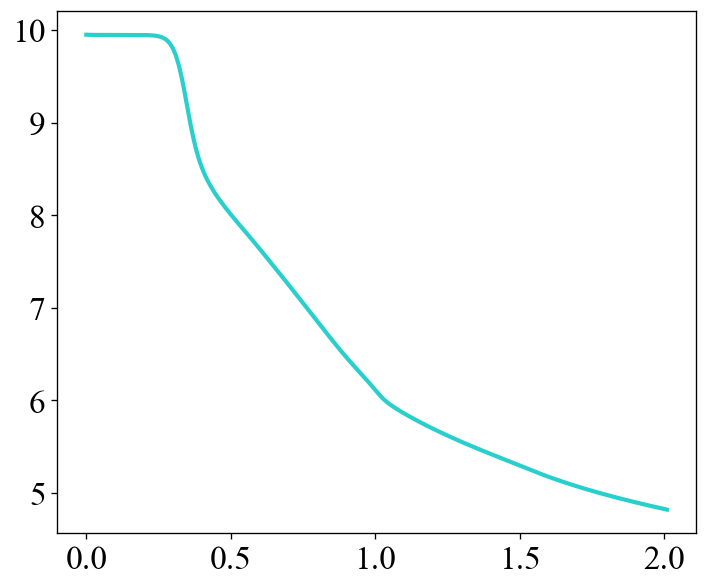

In [9]:
energy_gradient_total = energy_total[:, 0]
energy_non_linear_total = energy_total[:, 1]
energy = energy_gradient_total + energy_non_linear_total

# Journal of Computational Physics (Elsevier): Times New Roman for figures
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["mathtext.rm"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
ax.plot(t_total[:], energy[:] * dx**2, color="#29cfcc", lw=2.5)

from matplotlib.ticker import FuncFormatter, MultipleLocator

config_title = f"{save_path}/{method}/{method}_coarsening_Nx{Nx}_Ny{Ny}_dt{dt}_eps{eps:.4f}_T{T}_bc{bc}_energy_case3"


label_font = {"fontsize": 20, "fontfamily": "Times New Roman"}
ax.tick_params(axis="both", labelsize=20)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")
# ax.legend(loc="best", frameon=True, prop={"family": "serif", "size": 14})
# ax.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
# ax.set_yticks([6, 8, 10, 12])
fig.tight_layout()


if save:
    energy_save_path = f"{config_title}.pdf"
    fig.savefig(energy_save_path, bbox_inches="tight")
    print(f"Figure saved to {energy_save_path}")
plt.show()

2.010000000000001


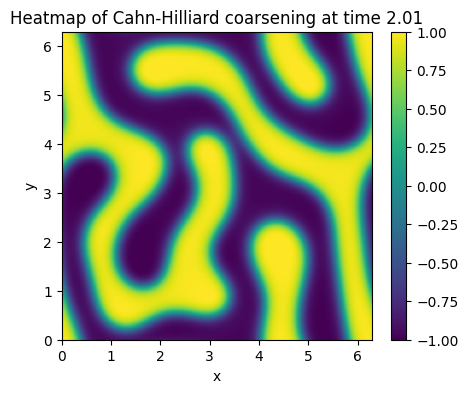

In [10]:
print(t_total[-1])
my_solver.display(u_total[-1], [a_x, b_x, a_y, b_y], t_total[-1], save=False)

### Generate animation

In [13]:
import matplotlib.animation as animation

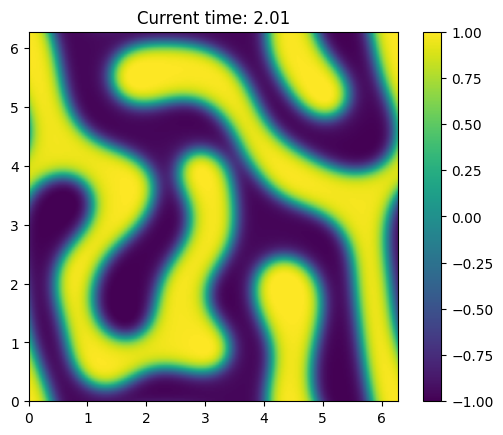

In [14]:
utils.generate_anime(u_total, t_total, [a_x, b_x, a_y, b_y], save=True)

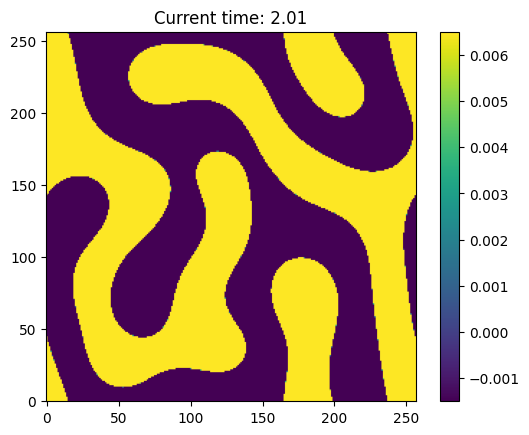

In [15]:
fig, ax = plt.subplots()
cax = ax.imshow(u_total[0], cmap='viridis', origin='lower')
fig.colorbar(cax)

def update(frame):
    cax.set_data(u_total[frame])
    ax.set_title(f'Current time: {round(t_total[frame], 5)}')
    return [cax]

ani = animation.FuncAnimation(fig, update, frames=len(u_total), blit=True)

# Save as GIF
ani.save('Natural Timestepping Cahn-Hilliard Coarsening.gif', writer='pillow', fps=10)